In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [1]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 11)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

ModuleNotFoundError: No module named 'src'

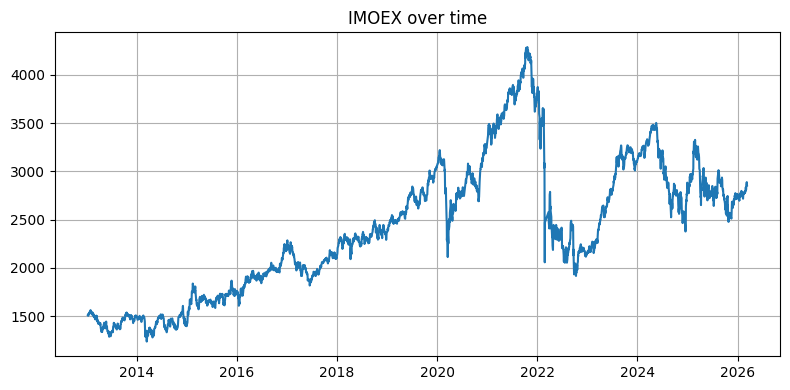

In [2]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [3]:
from src.get_features import add_log_returns, add_volatility

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])

Model is not converging.  Current: 80591.29531023283 is not greater than 80591.46343199015. Delta is -0.16812175732047763
Model is not converging.  Current: 84284.34872520405 is not greater than 84284.43853216054. Delta is -0.08980695648642723
Model is not converging.  Current: 84984.32714966775 is not greater than 84984.37120840471. Delta is -0.04405873696669005
Model is not converging.  Current: 84562.51306743149 is not greater than 84567.26629812895. Delta is -4.753230697460822
Model is not converging.  Current: 85212.3325099698 is not greater than 85212.3843497284. Delta is -0.051839758598362096
Model is not converging.  Current: 86193.85742907993 is not greater than 86193.86630000368. Delta is -0.008870923746144399
Model is not converging.  Current: 83533.45114322797 is not greater than 83609.42891260325. Delta is -75.97776937528397
Model is not converging.  Current: 84560.05972599845 is not greater than 84560.06246486164. Delta is -0.0027388631860958412
Model is not converging.  

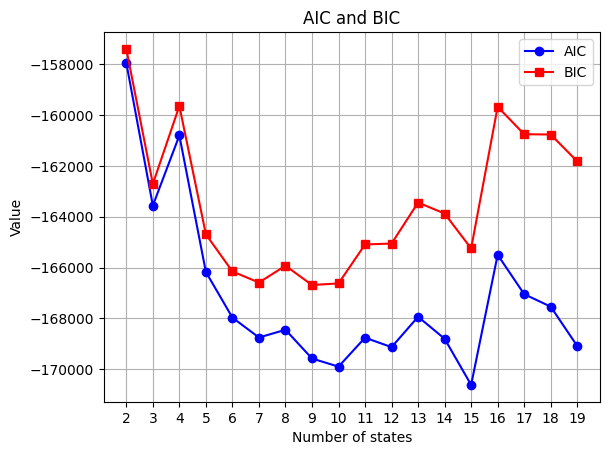

In [5]:
from src.train_hmm import train_hmm
features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]

candles = candles.dropna()
X = candles[features].values

bics = []
aics = []
ks = range(2, 20)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [8]:
model = train_hmm(X, n_states=3, n_iter=5000)

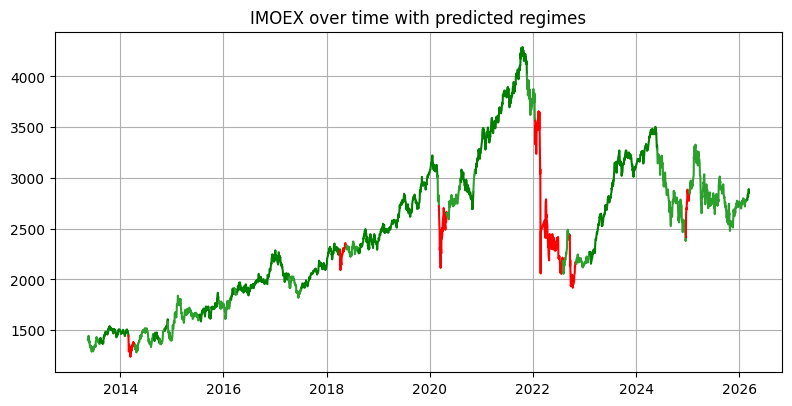

In [9]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [10]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})

print(statistics)

       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.005612  0.022723     0.007986  0.003032  1779
1          -0.017038  0.093090     0.027970  0.027538   261
2          -0.000533  0.036995     0.012135  0.005123  1180


[[9.93673009e-001 1.12586200e-003 5.20112934e-003]
 [4.02186003e-243 9.76951273e-001 2.30487271e-002]
 [1.02908877e-002 3.38327520e-003 9.86325837e-001]]


Text(50.722222222222214, 0.5, 'from')

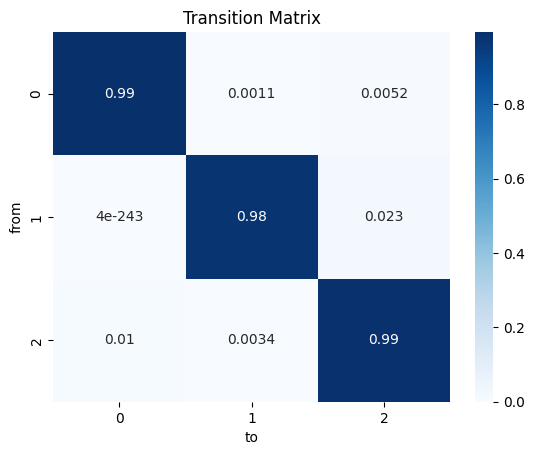

In [34]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues")
print(model.transmat_)
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")

In [53]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": expected_duration
})
print(df)

   Stay Probability  Expected regime duration (days)
0          0.993673                       158.053006
1          0.976951                        43.386344
2          0.986326                        73.130619
